# Análises Gerais

* Importando Bibliotecas

In [1]:
import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt
import numpy as np
from plotly.subplots import make_subplots

* Configuração do caminho dos arquivos analisados

In [2]:
caminho_base = r"C:\Users\User\Desktop\Simulação Final"
arq_fixo = os.path.join(caminho_base, 'Setpoint e Horario Fixo', "Simulacao01_R06.csv")
arq_dinamico = os.path.join(caminho_base, 'Setpoint e Horario Dinamico', "Simulacao01_R06.csv")
arq_hor_dinamico = os.path.join(caminho_base, 'Horario Dinamico', "Simulacao01_R06.csv")
arq_set_dinamico = os.path.join(caminho_base, 'Setpoint Dinamico', "Simulacao01_R06.csv")

# Análise Energia

* Calculando Consumo

In [3]:
import os
import pandas as pd

# Constante de conversão de Joules para kWh
J_TO_KWH = 2.77778e-7

def calcular_consumo_total(caminho):
    if not os.path.exists(caminho):
        print(f"ERRO: Arquivo não encontrado em {caminho}")
        return None, None
    
    df = pd.read_csv(caminho)
    # Limpa nomes das colunas
    df.columns = [col.strip() for col in df.columns]
    
    print(f"Arquivo analisado: {os.path.basename(caminho)} | Total de linhas: {len(df)}")
    
    # Soma colunas de energia
    cols_energia = [col for col in df.columns if 'Electricity Energy' in col]
    total_kwh = df[cols_energia].sum().sum() * J_TO_KWH
    
    return total_kwh, cols_energia

# --- Processando todos os arquivos ---
consumo_f, colunas_f = calcular_consumo_total(arq_fixo)
consumo_d, colunas_d = calcular_consumo_total(arq_dinamico)
consumo_hor, colunas_hor = calcular_consumo_total(arq_hor_dinamico)
consumo_set, colunas_set = calcular_consumo_total(arq_set_dinamico)

# --- Exibindo os Resultados ---
if all([consumo_f, consumo_d, consumo_hor, consumo_set]):
    economia_d = ((consumo_f - consumo_d) / consumo_f) * 100
    economia_hor = ((consumo_f - consumo_hor) / consumo_f) * 100
    economia_set = ((consumo_f - consumo_set) / consumo_f) * 100
    
    print("-" * 50)
    print("RESULTADO DA ANÁLISE DE CONSUMO")
    print(f"Consumo Fixo:        {consumo_f:.2f} kWh")
    print(f"Consumo Dinâmico:    {consumo_d:.2f} kWh (Economia: {economia_d:.2f}%)")
    print(f"Consumo Hor. Din.:   {consumo_hor:.2f} kWh (Economia: {economia_hor:.2f}%)")
    print(f"Consumo Set. Din.:   {consumo_set:.2f} kWh (Economia: {economia_set:.2f}%)")
    print("-" * 50)

Arquivo analisado: Simulacao01_R06.csv | Total de linhas: 105120
Arquivo analisado: Simulacao01_R06.csv | Total de linhas: 105120
Arquivo analisado: Simulacao01_R06.csv | Total de linhas: 105120
Arquivo analisado: Simulacao01_R06.csv | Total de linhas: 105120
--------------------------------------------------
RESULTADO DA ANÁLISE DE CONSUMO
Consumo Fixo:        17092.68 kWh
Consumo Dinâmico:    15856.92 kWh (Economia: 7.23%)
Consumo Hor. Din.:   16112.63 kWh (Economia: 5.73%)
Consumo Set. Din.:   16695.52 kWh (Economia: 2.32%)
--------------------------------------------------


* Gráficos

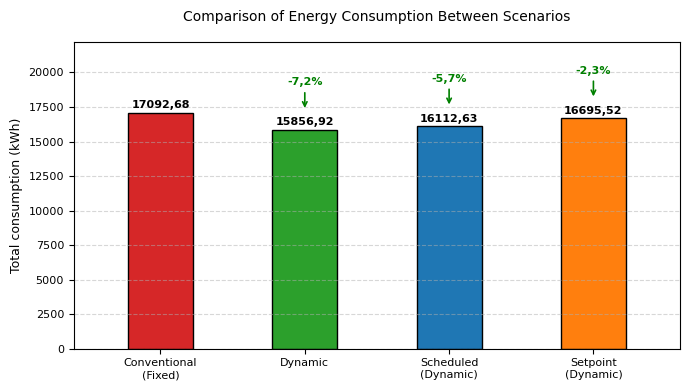

In [4]:
# Categorias e valores atualizados para incluir os quatro cenários
categorias = ['Conventional\n(Fixed)', 'Dynamic', 'Scheduled\n(Dynamic)', 'Setpoint\n(Dynamic)']
valores = [consumo_f, consumo_d, consumo_hor, consumo_set] 
economias = [0, economia_d, economia_hor, economia_set]
cores = ['#d62728', '#2ca02c', '#1f77b4', '#ff7f0e']

plt.figure(figsize=(7, 4))
bars = plt.bar(categorias, valores, color=cores, width=0.45, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    label = f'{yval:.2f}'.replace('.', ',')
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(valores)*0.01), 
             label, ha='center', va='bottom', fontsize=8, fontweight='bold')

# Adicionando anotações de redução percentual para cada modelo dinâmico
for i in range(1, len(categorias)):
    eco = economias[i]
    plt.annotate(f'-{eco:.1f}%'.replace('.', ','), 
                 xy=(i, valores[i] + (max(valores) * 0.08)), 
                 xytext=(i, valores[i] + (max(valores) * 0.18)),
                 ha='center', va='bottom',
                 fontsize=8, fontweight='bold', color='green',
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

plt.ylabel('Total consumption (kWh)', fontsize=9)
plt.title('Comparison of Energy Consumption Between Scenarios', fontsize=10, pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(valores) * 1.30)
plt.xlim(-0.6, len(categorias) - 0.4)

plt.tick_params(axis='x', labelsize=8)
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

# Análise Conforto

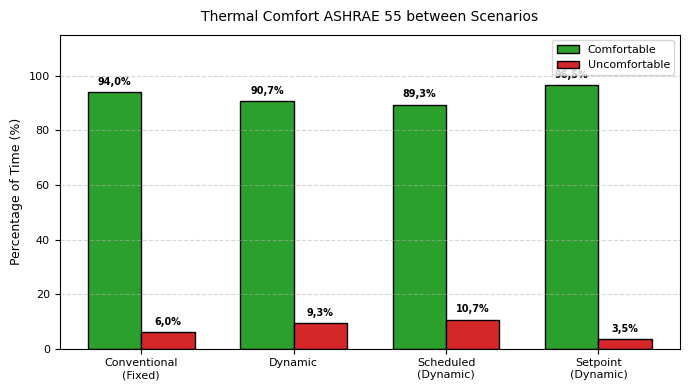

In [6]:
# --- Função de cálculo necessária para o código funcionar ---
def calcular_percentual_ashrae(caminho):
    df = pd.read_csv(caminho)
    df.columns = [col.strip() for col in df.columns]
    
    col_not_comfort = [col for col in df.columns if 'Not Comfortable Time [hr]' in col][0]
    col_ocupacao = [col for col in df.columns if 'People Occupant Count' in col][0]
    
    df_ocupado = df[df[col_ocupacao] > 0].copy()
    
    total_desconforto_h = df_ocupado[col_not_comfort].sum()
    total_horas_ocupadas = len(df_ocupado) * (5/60)
    
    perc_desconfortavel = (total_desconforto_h / total_horas_ocupadas) * 100
    perc_confortavel = 100 - perc_desconfortavel
    
    return perc_confortavel, perc_desconfortavel

# --- Processando o conforto para todos os quatro cenários ---
c_fixo, d_fixo = calcular_percentual_ashrae(arq_fixo)
c_din, d_din = calcular_percentual_ashrae(arq_dinamico)
c_hor, d_hor = calcular_percentual_ashrae(arq_hor_dinamico)
c_set, d_set = calcular_percentual_ashrae(arq_set_dinamico)

# --- Dados para o Gráfico ---
categorias = ['Conventional\n(Fixed)', 'Dynamic', 'Scheduled\n(Dynamic)', 'Setpoint\n(Dynamic)']
confortavel = [c_fixo, c_din, c_hor, c_set]
desconfortavel = [d_fixo, d_din, d_hor, d_set]

# Ajuste de tamanho da figura para acomodar os 4 cenários confortavelmente
plt.figure(figsize=(7, 4))

x = np.arange(len(categorias))
width = 0.35 

# Criando as barras agrupadas
bars1 = plt.bar(x - width/2, confortavel, width, label='Comfortable', color='#2ca02c', edgecolor='black')
bars2 = plt.bar(x + width/2, desconfortavel, width, label='Uncomfortable', color='#d62728', edgecolor='black')

# Estilização
plt.ylabel('Percentage of Time (%)', fontsize=9)
plt.title('Thermal Comfort ASHRAE 55 between Scenarios', fontsize=10, pad=10)
plt.xticks(x, categorias, fontsize=8)
plt.ylim(0, 115) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legenda otimizada
plt.legend(fontsize=8, frameon=True)

# Função de rotulagem com tamanho ajustado
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.1f}%'.replace('.', ',')
        plt.text(bar.get_x() + bar.get_width()/2, height + 2, 
                 label, ha='center', va='bottom', fontsize=7, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

plt.tick_params(axis='x', labelsize=8) 
plt.tick_params(axis='y', labelsize=8) 

plt.tight_layout()
plt.show()